## Vectorisation Techniques

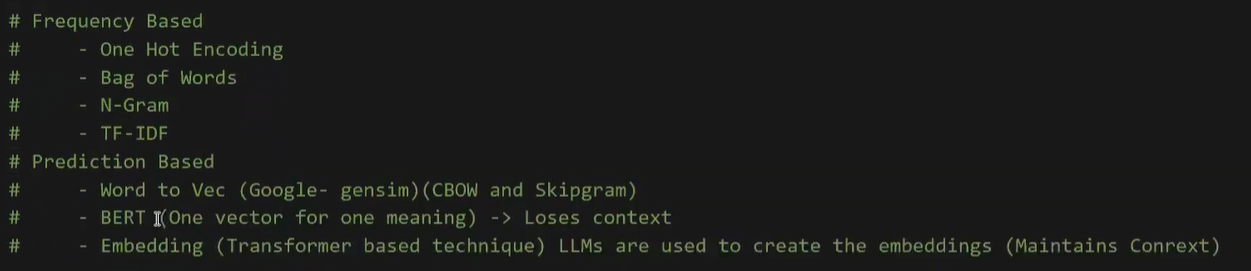

## Embeddings

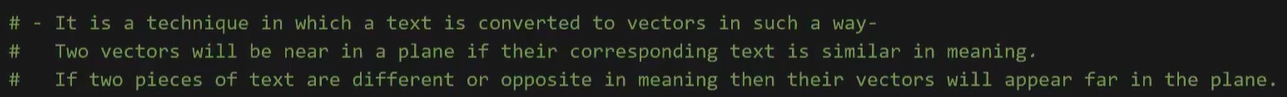

### Example

In [ ]:
# Comparing TF-IDF with Embeddings

#### TF-IDF

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
sentences = [
    'I love dogs',
    'I adore puppies',
    'The stock market is crashed.'
]

In [10]:
vectoriser = TfidfVectorizer()

tfidf_metrics = vectoriser.fit_transform(sentences)

In [11]:
tfidf_metrics.toarray()

array([[0.        , 0.        , 0.70710678, 0.        , 0.70710678,
        0.        , 0.        , 0.        , 0.        ],
       [0.70710678, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.70710678, 0.        , 0.        ],
       [0.        , 0.4472136 , 0.        , 0.4472136 , 0.        ,
        0.4472136 , 0.        , 0.4472136 , 0.4472136 ]])

In [13]:
tfidf_metrics.toarray().shape

(3, 9)

In [12]:
similarity = cosine_similarity(tfidf_metrics)

similarity

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

TF-IDF is showing no similarity bw the first and second sentences. No matching (fails to understand the semantic meaning). It just says each sentence is similar to itself.

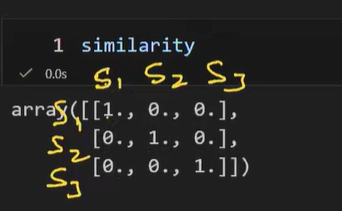

#### Embedding Technique

In [15]:
import os
from openai import OpenAI

In [16]:
client = OpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'))

In [23]:
def get_embeddings(text):
    response = client.embeddings.create(
        model='text-embedding-3-small',
        input=text
    )
    return response.data[0].embedding

In [24]:
embeddings = []

for s in sentences:
    emb = get_embeddings(s)
    embeddings.append(emb)

In [28]:
embeddings

[[0.037245556712150574,
  -0.04158462956547737,
  -0.026563063263893127,
  0.018182262778282166,
  0.013567866757512093,
  -0.02588026411831379,
  -0.004231698345392942,
  0.04488849267363548,
  -0.056826453655958176,
  -0.024206306785345078,
  0.0015294135082513094,
  -0.009327908046543598,
  -0.022058796137571335,
  -0.01296215783804655,
  0.0016354124527424574,
  -0.0016230229521170259,
  -0.05779558792710304,
  -0.0044877477921545506,
  0.05369879677891731,
  0.00828168448060751,
  -0.00953715294599533,
  0.050659243017435074,
  -0.053522590547800064,
  -0.031078342348337173,
  0.003782923799008131,
  0.02469087392091751,
  0.030549725517630577,
  0.016915781423449516,
  0.04416164383292198,
  -0.028721587732434273,
  -0.01094680093228817,
  -0.004754810128360987,
  5.2268154831836e-05,
  -0.01052831206470728,
  0.027422066777944565,
  0.003496588906273246,
  -0.05299397185444832,
  -0.019702039659023285,
  0.006888555362820625,
  0.06074703857302666,
  0.0041601150296628475,
  -0.

In [ ]:
embeddings_similarity = cosine_similarity(embeddings)

embeddings_similarity
# S1 and S2 are 76% similar
# S1 and S3 are 6%
# S2 and S3 are 1%

array([[1.        , 0.76473633, 0.06077381],
       [0.76473633, 1.        , 0.01765685],
       [0.06077381, 0.01765685, 1.        ]])

In [29]:
import numpy as np

In [33]:
np.array(embeddings).shape

# 3 Sentences
# Each sentence has 1536 scalar values. The vector size is 1536.
# Each vector is compared against others. That's why the similarity size is 3*3

(3, 1536)

### What is Cosine Similarity?

Embeddings do not compare two vectors based on their length because they might be different.

One sentence might be lengthy and another one could be small. So, they are compared based upon the direction.


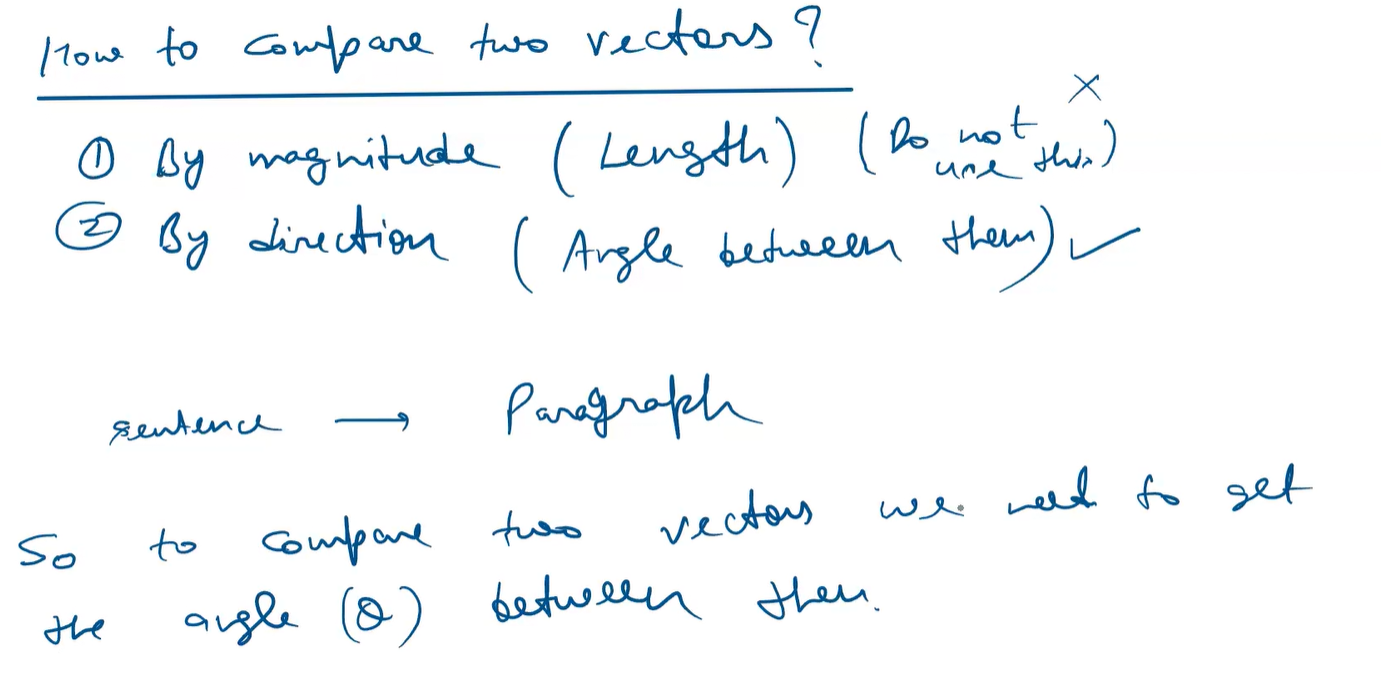


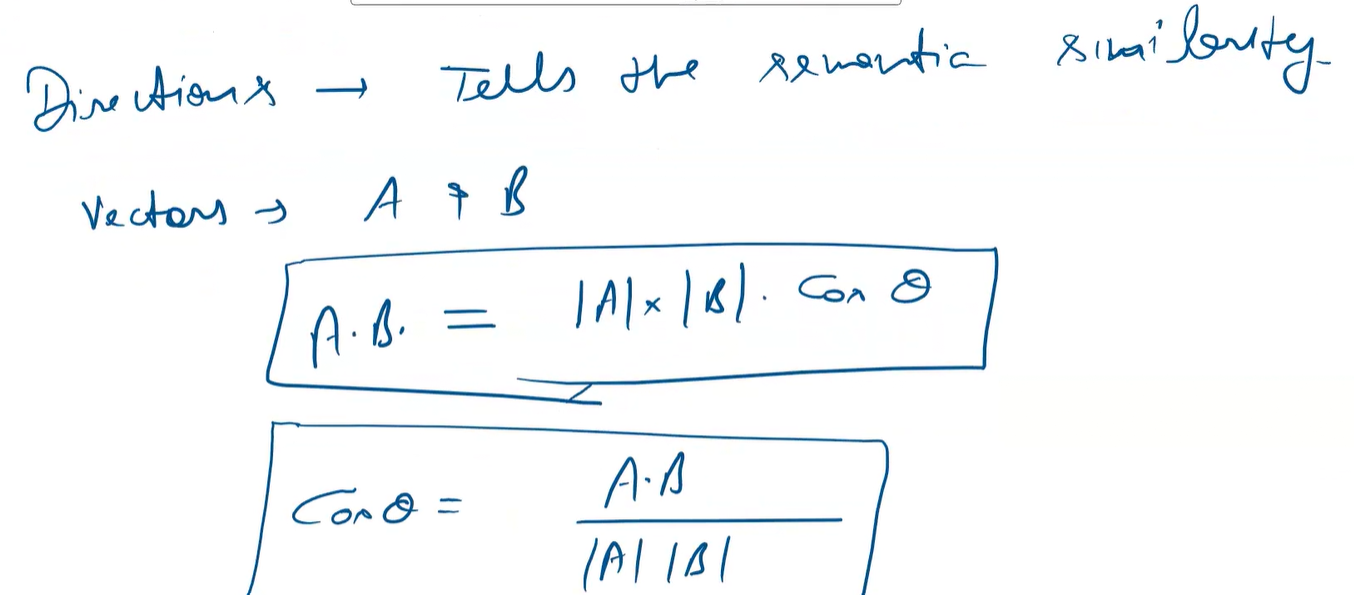

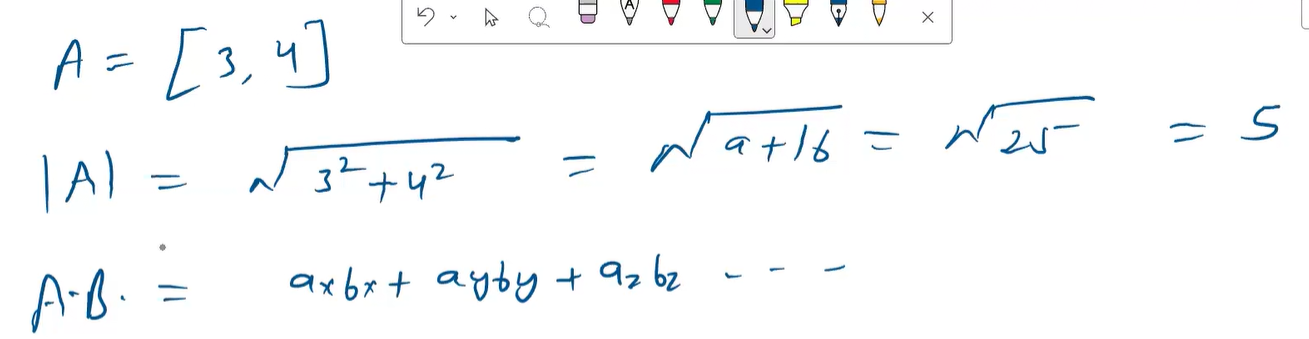


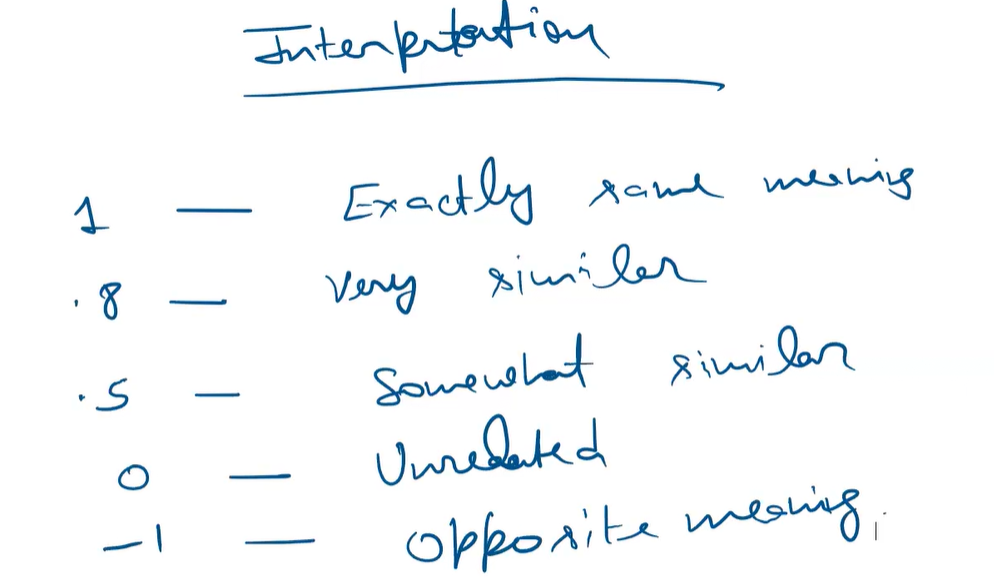